# 🧠 CNN from Scratch — Impact du Preprocessing (Images Masquées)

**Objectif** : Mesurer l'impact du preprocessing sur un CNN from scratch, avec des images masquées (poumons segmentés).

**Ce qu'on fixe** : L'architecture CNN (4 blocs conv), l'augmentation, les hyperparamètres.

**Ce qu'on fait varier** : Le pipeline de preprocessing appliqué avant l'entrée dans le modèle.

**Pourquoi pas de feature engineering ?** En CNN, les couches convolutives *sont* l'extraction de features. Elles apprennent automatiquement des représentations hiérarchiques : bords → textures → structures anatomiques → patterns pathologiques. Le preprocessing influe sur la qualité du signal fourni au modèle.

| Section | Description |
|---------|-------------|
| 1. Config | Dataset, IMG_SIZE, expériences de preprocessing |
| 2. Chargement | Split 70/15/15, class weights |
| 3. Preprocessing | Fonctions CLAHE, gaussian blur, pipeline dynamique |
| 4. Architecture | CNN 4 blocs + augmentation intégrée |
| 5. Expériences | Boucle d'entraînement + évaluation |
| 6. Comparaison | Tableau, courbes, meilleur modèle |
| 7. Grad-CAM | Visualisation des zones d'attention du meilleur modèle |

## 1. Imports

In [1]:
import os
import random
from copy import deepcopy
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ── Reproductibilité ──
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU ──
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f"TensorFlow {tf.__version__} — GPU {'activé (' + gpus[0].name + ')' if gpus else 'non détecté (CPU)'}")

TensorFlow 2.19.0 — GPU activé (/physical_device:GPU:0)


---
## ⚙️ 2. Configuration

**Modifiez cette cellule** pour changer : dataset, résolution, expériences de preprocessing.

In [3]:
# ════════════════════════════════════════════════════════════
#  CONFIGURATION — Modifier ici selon vos besoins
# ════════════════════════════════════════════════════════════

# --- Dataset ---
# Images masquées : poumons segmentés → moins de bruit de fond


# We detect if we are in COLAB : 

if 'COLAB_GPU' in os.environ:

    print("🚀 Environnement : Google Colab détecté")
    
    # On monte les données dans content/ (pour Google Colab)

    from google.colab import drive
    import subprocess
    drive.mount('/content/drive')

    dataset_archive = '/content/drive/MyDrive/DS_COVID/toshare/masked_full_dataset_256_256_L.zip'


    print("📦 Extraction dataset...")
    os.makedirs('./data/processed/', exist_ok=True)
    subprocess.run(['unzip', '-o', '-q', dataset_archive, '-d',  './data/processed/'])

    DATA_DIR = Path("./data/processed/masked_full_dataset_256_256_L")

else:

    print("💻 Environnement : Local détecté")

    DATA_DIR = Path("../data/processed/masked_full_dataset_256_256_L")

CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

# --- Taille des images ---
# (128, 128) : bon compromis vitesse/qualité pour expériences
# (224, 224) : pour l'entraînement final
IMG_SIZE = (128, 128)

# --- Entraînement ---
BATCH_SIZE = 32
EPOCHS     = 50    # EarlyStopping arrêtera avant si convergence

# --- Expériences de preprocessing ---
# Les fonctions sont appliquées dans l'ordre sur les images raw [0, 255].
# La normalisation [0,1] est toujours appliquée en dernier.
# Étapes disponibles : "gaussian_blur", "clahe"
PREPROCESSING_EXPERIMENTS = {
    "Baseline (normalize)": [],
    "+ Gaussian Blur":       ["gaussian_blur"],
    "+ CLAHE":               ["clahe"],
    "Blur → CLAHE":          ["gaussian_blur", "clahe"],  # débruitage PUIS contraste
    "CLAHE → Blur":          ["clahe", "gaussian_blur"],  # contraste PUIS lissage
}

print(f"Dataset    : {DATA_DIR}")
print(f"Classes    : {CLASS_NAMES}")
print(f"IMG_SIZE   : {IMG_SIZE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Epochs max : {EPOCHS}")
print(f"Expériences: {list(PREPROCESSING_EXPERIMENTS.keys())}")
print(f"\nDistribution (déséquilibre à gérer) :")
print(f"  COVID: 3616 | Lung_Opacity: 6012 | Normal: 10192 | Viral Pneumonia: 1345")

Mounted at /content/drive
📦 Extraction dataset...
Dataset    : data/processed/masked_full_dataset_256_256_L
Classes    : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
IMG_SIZE   : (128, 128)
Batch size : 32
Epochs max : 50
Expériences: ['Baseline (normalize)', '+ Gaussian Blur', '+ CLAHE', 'Blur → CLAHE', 'CLAHE → Blur']

Distribution (déséquilibre à gérer) :
  COVID: 3616 | Lung_Opacity: 6012 | Normal: 10192 | Viral Pneumonia: 1345


---
## 📂 3. Chargement des données

Split **70 / 15 / 15** (train / val / test). Le split est fixé par `seed=SEED` et `stratify` implicite de Keras.
Les **class weights** sont calculés sur le train set pour compenser le déséquilibre.

In [4]:
def load_datasets(data_dir, img_size, batch_size, seed=42):
    """Charge train/val/test depuis un répertoire structuré par classe.
    Split : 70% train, 15% val, 15% test.
    Retourne les datasets RAW (non normalisés) pour permettre CLAHE.
    """
    kwargs = dict(
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        color_mode='grayscale',
        label_mode='categorical',
    )
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.30, subset='training', shuffle=True, **kwargs
    )
    val_test_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.30, subset='validation', shuffle=True, **kwargs
    )
    n_val_test = tf.data.experimental.cardinality(val_test_ds).numpy()
    val_ds  = val_test_ds.take(n_val_test // 2)
    test_ds = val_test_ds.skip(n_val_test // 2)

    print(f"Train : {tf.data.experimental.cardinality(train_ds).numpy()} batches")
    print(f"Val   : {tf.data.experimental.cardinality(val_ds).numpy()} batches")
    print(f"Test  : {tf.data.experimental.cardinality(test_ds).numpy()} batches")
    print(f"Classes : {train_ds.class_names}")
    return train_ds, val_ds, test_ds


def compute_class_weights(train_ds):
    """Calcule les poids de classes sur le train set."""
    labels = np.concatenate([np.argmax(y, axis=1) for _, y in train_ds])
    weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    cw = dict(enumerate(weights))
    print("Poids des classes :")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:20s}: {cw[i]:.3f}")
    return cw


# Chargement (une seule fois — images raw [0,255])
train_ds_raw, val_ds_raw, test_ds_raw = load_datasets(DATA_DIR, IMG_SIZE, BATCH_SIZE, SEED)
class_weight = compute_class_weights(train_ds_raw)

Found 21165 files belonging to 4 classes.
Using 14816 files for training.
Found 21165 files belonging to 4 classes.
Using 6349 files for validation.
Train : 463 batches
Val   : 99 batches
Test  : 100 batches
Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Poids des classes :
  COVID               : 1.465
  Lung_Opacity        : 0.875
  Normal              : 0.519
  Viral Pneumonia     : 4.022


---
## 🧹 4. Fonctions de preprocessing

Toutes les fonctions travaillent sur des images **raw [0, 255]**.  
La normalisation finale `[0, 1]` est **toujours appliquée en dernier**.

| Étape | Description | Impact attendu |
|-------|-------------|----------------|
| `normalize` | Rescaling [0,255] → [0,1] | Toujours appliqué |
| `gaussian_blur` | Lissage gaussien (σ=1, k=5) | Réduit le bruit haute fréquence |
| `clahe` | Contraste adaptatif local (clip=2.0) | Améliore le contraste des structures |


In [5]:
# ── CLAHE via tf.py_function (nécessite cv2, non-TF-natif) ──
def _apply_clahe_batch(imgs_tensor):
    """Applique CLAHE sur un batch numpy. Entrée [0,255], sortie [0,255] float32."""
    imgs = imgs_tensor.numpy()
    result = np.empty_like(imgs, dtype=np.float32)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    for i in range(imgs.shape[0]):
        img_u8 = imgs[i, :, :, 0].astype(np.uint8)
        result[i, :, :, 0] = clahe.apply(img_u8).astype(np.float32)
    return result

def apply_clahe(images, labels):
    images = tf.py_function(_apply_clahe_batch, [images], tf.float32)
    images.set_shape([None, None, None, 1])
    return images, labels


# ── Gaussian Blur via tf.py_function ──
def _apply_gaussian_blur_batch(imgs_tensor):
    """Applique un flou gaussien. Entrée [0,255], sortie [0,255] float32."""
    imgs = imgs_tensor.numpy()
    result = np.empty_like(imgs, dtype=np.float32)
    for i in range(imgs.shape[0]):
        img = imgs[i, :, :, 0].astype(np.float32)
        result[i, :, :, 0] = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)
    return result

def apply_gaussian_blur(images, labels):
    images = tf.py_function(_apply_gaussian_blur_batch, [images], tf.float32)
    images.set_shape([None, None, None, 1])
    return images, labels


# ── Normalisation [0,1] ──
def apply_normalize(images, labels):
    return tf.cast(images, tf.float32) / 255.0, labels


# ── Registre des étapes disponibles ──
STEP_REGISTRY = {
    "clahe":         apply_clahe,
    "gaussian_blur": apply_gaussian_blur,
}


def build_pipeline(ds_raw, steps, augment=False, augmentation_layer=None):
    """Construit le pipeline tf.data : étapes de preprocessing → normalize → (augment).
    
    L'augmentation est intégrée dans le modèle Keras (pas ici),
    donc ce flag est laissé pour usage futur.
    """
    ds = ds_raw
    for step in steps:
        ds = ds.map(STEP_REGISTRY[step], num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(apply_normalize, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)


print("Fonctions de preprocessing chargées.")
print(f"Étapes disponibles : {list(STEP_REGISTRY.keys())}")

Fonctions de preprocessing chargées.
Étapes disponibles : ['clahe', 'gaussian_blur']


---
## 🧠 5. Architecture CNN

**4 blocs convolutifs** : [32, 64, 128, 256] filtres — identique au notebook `deep_learning_pipeline`.

```
Input → [Augmentation] → Conv(32)+BN+ReLU+Pool → Conv(64)+BN+ReLU+Pool
      → Conv(128)+BN+ReLU+Pool → Conv(256)+BN+ReLU+Pool
      → GlobalAvgPool → Dense(256)+Dropout(0.5) → Softmax(4)
```

L'augmentation est intégrée dans le modèle : elle s'applique **uniquement au train** (désactivée en inférence automatiquement par Keras).

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), # ? Coeur à droite ?
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.1),
], name="data_augmentation")


def build_cnn(input_shape, num_classes=4, filters=(32, 64, 128, 256)):
    """CNN 4 blocs convolutifs + augmentation intégrée."""
    inputs = layers.Input(shape=input_shape, name="input")
    x = data_augmentation(inputs)  # désactivé automatiquement en inférence

    for f in filters:
        x = layers.Conv2D(f, (3, 3), padding='same', name=f"conv_{f}")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    return Model(inputs, outputs, name="cnn_scratch")


# Vérification de l'architecture
input_shape = (*IMG_SIZE, 1)  # (H, W, channels=1 pour grayscale)
_tmp = build_cnn(input_shape, NUM_CLASSES)
_tmp.summary()
del _tmp

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32 (Conv2D)                │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_128 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_256 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 456,580 (1.74 MB)

 Trainable params: 455,620 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

---
## 🚀 6. Exécution des expériences

Pour chaque expérience, on :
1. Construit le pipeline de preprocessing sur train/val/test
2. Instancie un CNN **frais** (même architecture, poids aléatoires)
3. Entraîne avec EarlyStopping + ReduceLROnPlateau + class_weight
4. Évalue sur le test set

In [ ]:
def run_experiment(exp_name, steps, train_raw, val_raw, test_raw,
                   input_shape, num_classes, class_weight, epochs, batch_size):
    """Entraîne un CNN from scratch avec le pipeline de preprocessing donné."""
    print(f"\n{'═'*70}")
    print(f"  {exp_name}  |  steps={steps or ['normalize']}")
    print(f"{'═'*70}")

    # 1. Pipelines
    train_ds = build_pipeline(train_raw, steps)
    val_ds   = build_pipeline(val_raw,   steps)
    test_ds  = build_pipeline(test_raw,  steps)

    # 2. Modèle frais
    tf.random.set_seed(SEED)
    model = build_cnn(input_shape, num_classes)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    # 3. Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', patience=5,
                          factor=0.5, min_lr=1e-7, verbose=1),
    ]

    # 4. Entraînement
    t0 = time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    t_train = time() - t0
    n_epochs = len(history.history['loss'])
    print(f"\n⏱  Durée : {t_train:.0f}s — {n_epochs} epochs effectuées")

    # 5. Évaluation test
    y_true, y_proba = [], []
    for images, labels in test_ds:
        y_proba.append(model.predict(images, verbose=0))
        y_true.append(labels.numpy())
    y_true   = np.argmax(np.concatenate(y_true),  axis=1)
    y_proba  = np.concatenate(y_proba)
    y_pred   = np.argmax(y_proba, axis=1)

    from sklearn.metrics import accuracy_score, f1_score
    acc    = accuracy_score(y_true, y_pred)
    f1_w   = f1_score(y_true, y_pred, average='weighted')
    f1_m   = f1_score(y_true, y_pred, average='macro')

    print(f"  Test → acc={acc:.4f}  f1_weighted={f1_w:.4f}  f1_macro={f1_m:.4f}")

    return {
        "model":    model,
        "history":  history,
        "y_true":   y_true,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
        "test_ds":  test_ds,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro":    f1_m,
        "n_epochs":    n_epochs,
        "train_time":  t_train,
    }


# ── Lancement de toutes les expériences ──
all_results = {}

for exp_name, steps in PREPROCESSING_EXPERIMENTS.items():
    all_results[exp_name] = run_experiment(
        exp_name, steps,
        train_ds_raw, val_ds_raw, test_ds_raw,
        input_shape=(*IMG_SIZE, 1),
        num_classes=NUM_CLASSES,
        class_weight=class_weight,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )

print(f"\n✅ {len(all_results)} expériences terminées !")

---
## 📊 7. Tableau comparatif

In [8]:
rows = []
for name, res in all_results.items():
    rows.append({
        "Expérience":     name,
        "Accuracy":       res["accuracy"],
        "F1 (weighted)":  res["f1_weighted"],
        "F1 (macro)":     res["f1_macro"],
        "Epochs":         res["n_epochs"],
        "Temps (s)":      res["train_time"],
    })

df_results = pd.DataFrame(rows).set_index("Expérience")

print("═" * 80)
print("  TABLEAU COMPARATIF — CNN from Scratch — Images Masquées")
print("  ⚠️  F1 macro = critère principal (équitable entre classes)")
print("═" * 80)

display(
    df_results.style
    .format({"Accuracy": "{:.4f}", "F1 (weighted)": "{:.4f}",
             "F1 (macro)": "{:.4f}", "Temps (s)": "{:.0f}"})
    .highlight_max(subset=["Accuracy", "F1 (weighted)", "F1 (macro)"], color="#90EE90")
    .highlight_min(subset=["F1 (macro)"], color="#FFCCCC")
)

════════════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF — CNN from Scratch — Images Masquées
  ⚠️  F1 macro = critère principal (équitable entre classes)
════════════════════════════════════════════════════════════════════════════════


,Accuracy,F1 (weighted),F1 (macro),Epochs,Temps (s)
Expérience,,,,,
Baseline (normalize),0.7080,0.6887,0.6489,12,189
+ Gaussian Blur,0.8372,0.8376,0.8279,47,719
+ CLAHE,0.8274,0.8250,0.8127,30,463
Blur → CLAHE,0.7630,0.7491,0.7163,14,220
CLAHE → Blur,0.7727,0.7500,0.7076,20,312


---
## 📈 8. Courbes d'entraînement

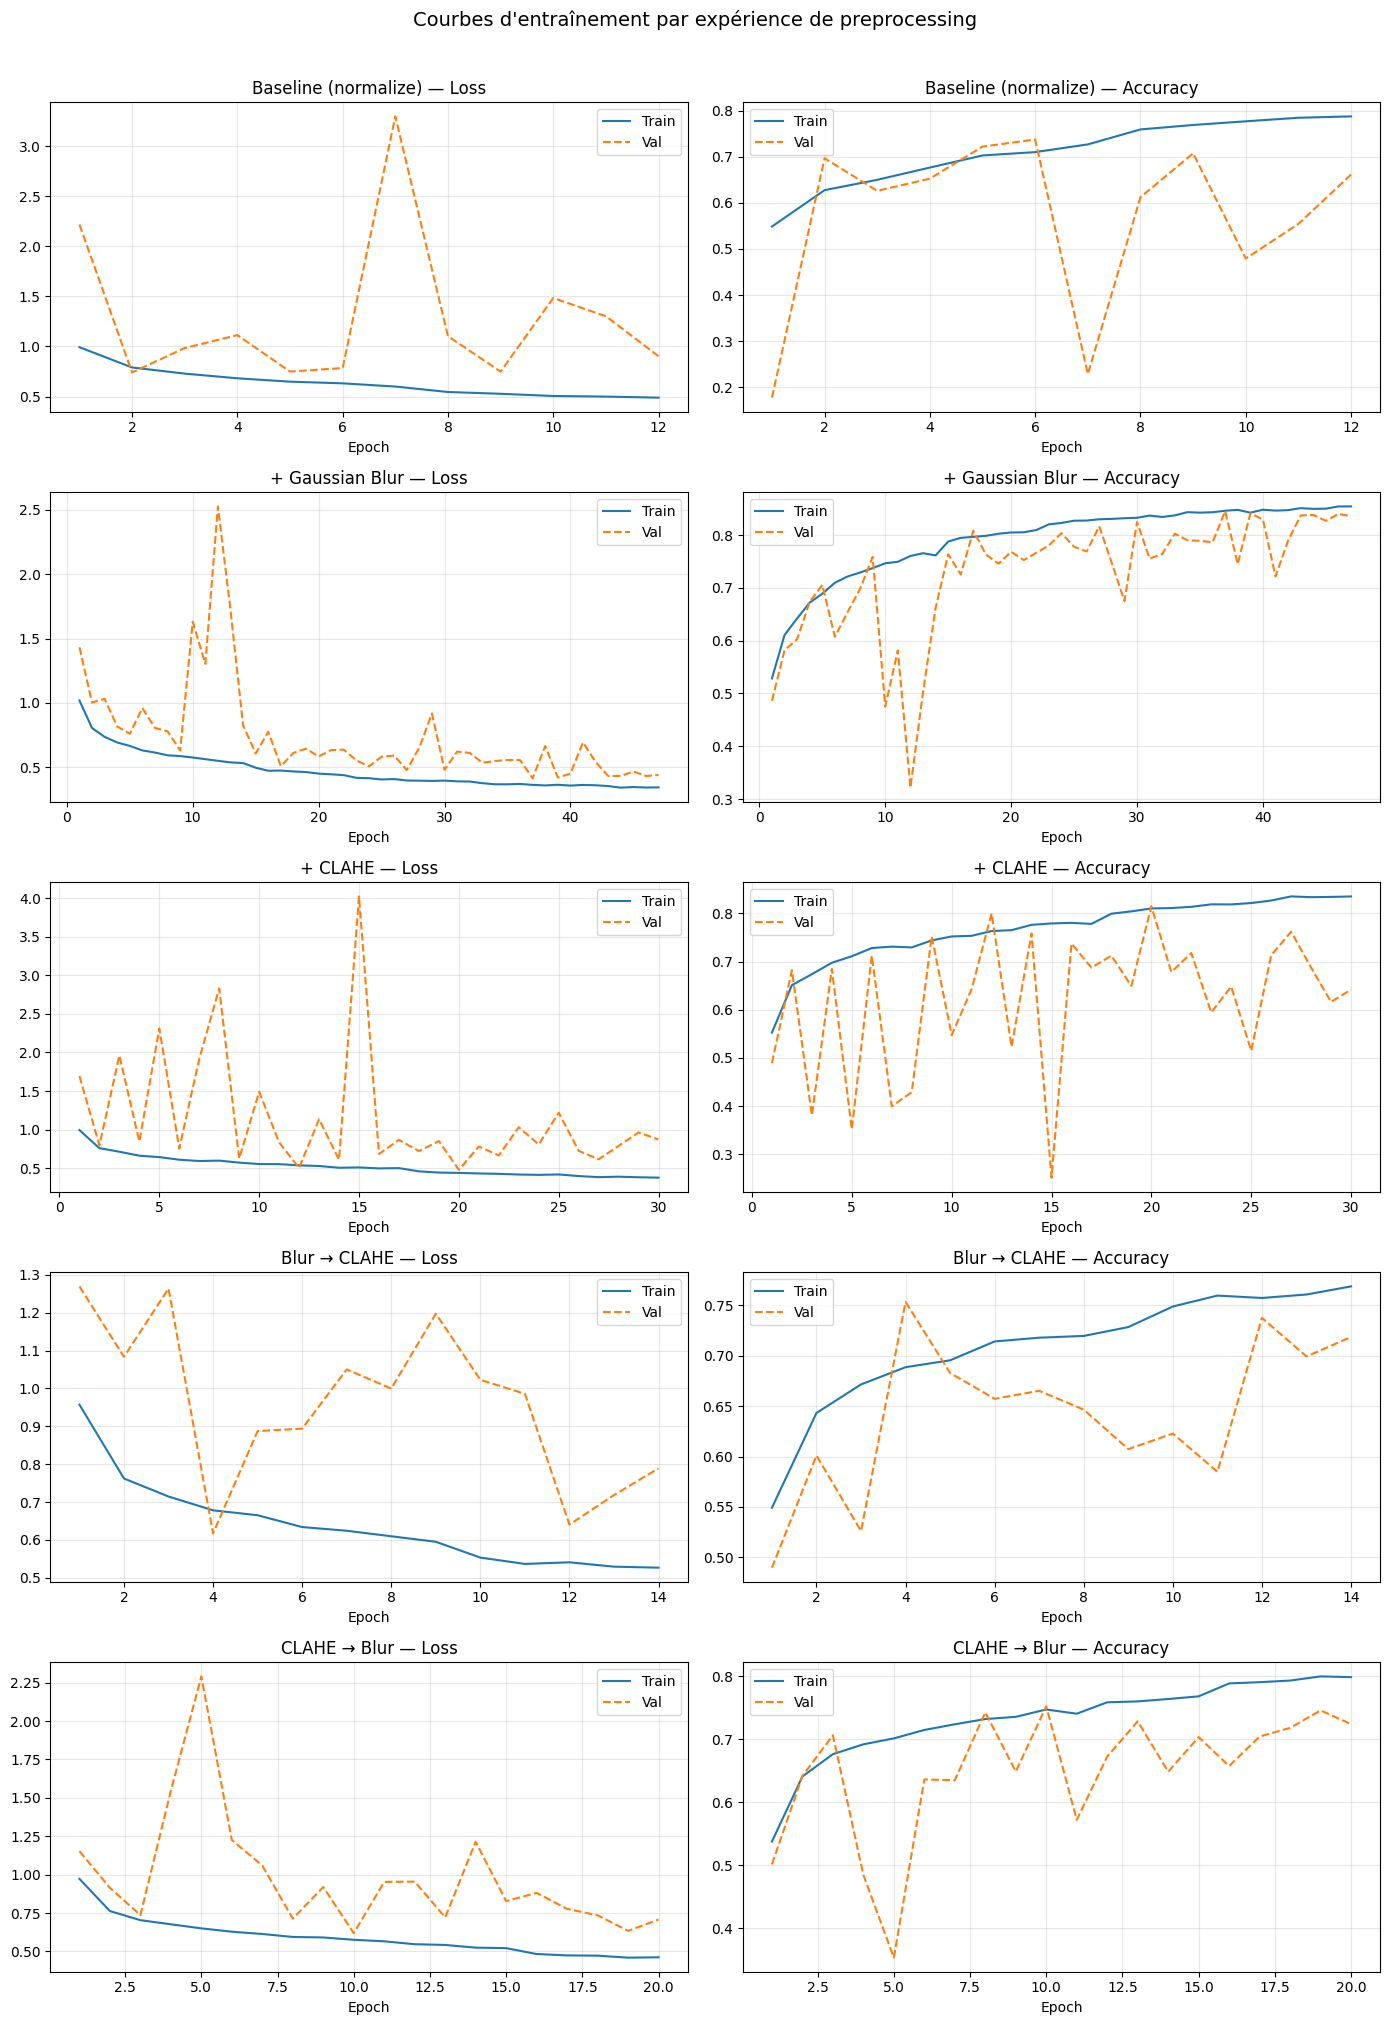

In [9]:
n_exp = len(all_results)
fig, axes = plt.subplots(n_exp, 2, figsize=(14, 4 * n_exp))
if n_exp == 1:
    axes = axes[np.newaxis, :]

for row, (name, res) in enumerate(all_results.items()):
    h = res["history"].history
    ep = range(1, len(h['loss']) + 1)

    axes[row, 0].plot(ep, h['loss'],     label='Train')
    axes[row, 0].plot(ep, h['val_loss'], label='Val', linestyle='--')
    axes[row, 0].set_title(f"{name} — Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(ep, h['accuracy'],     label='Train')
    axes[row, 1].plot(ep, h['val_accuracy'], label='Val', linestyle='--')
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.suptitle("Courbes d'entraînement par expérience de preprocessing", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 🏆 9. Analyse du meilleur modèle

🏆 Meilleure expérience : + Gaussian Blur
   Accuracy   : 0.8372
   F1 weighted: 0.8376
   F1 macro   : 0.8279
   Epochs     : 47


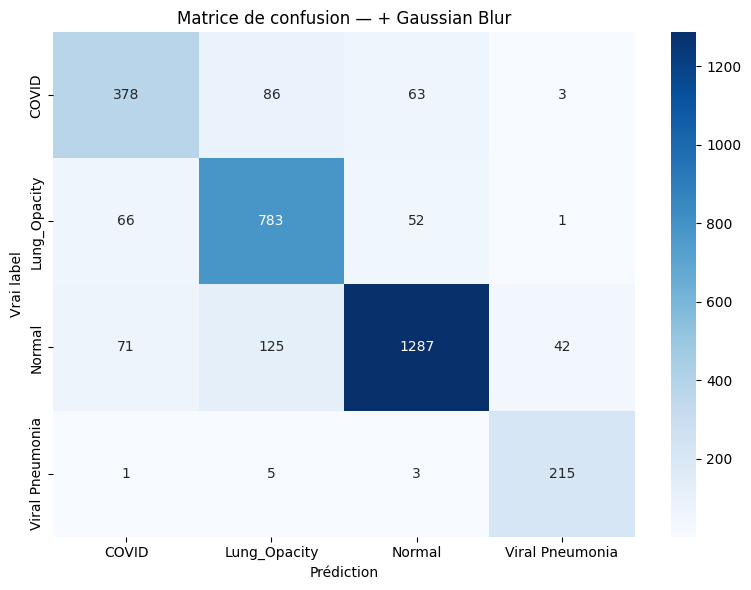


Classification Report :
                 precision    recall  f1-score   support

          COVID     0.7326    0.7132    0.7228       530
   Lung_Opacity     0.7838    0.8681    0.8238       902
         Normal     0.9160    0.8439    0.8785      1525
Viral Pneumonia     0.8238    0.9598    0.8866       224

       accuracy                         0.8372      3181
      macro avg     0.8140    0.8463    0.8279      3181
   weighted avg     0.8415    0.8372    0.8376      3181



In [10]:
# Meilleur modèle sur F1 macro
best_name = df_results["F1 (macro)"].idxmax()
best = all_results[best_name]

print(f"🏆 Meilleure expérience : {best_name}")
print(f"   Accuracy   : {best['accuracy']:.4f}")
print(f"   F1 weighted: {best['f1_weighted']:.4f}")
print(f"   F1 macro   : {best['f1_macro']:.4f}")
print(f"   Epochs     : {best['n_epochs']}")

# ── Matrice de confusion ──
cm = confusion_matrix(best['y_true'], best['y_pred'])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vrai label')
ax.set_title(f"Matrice de confusion — {best_name}")
plt.tight_layout()
plt.show()

# ── Classification report ──
print("\nClassification Report :")
print(classification_report(best['y_true'], best['y_pred'], target_names=CLASS_NAMES, digits=4))

---
## 🔥 10. Heatmap comparative

Visualisation rapide des métriques par expérience.

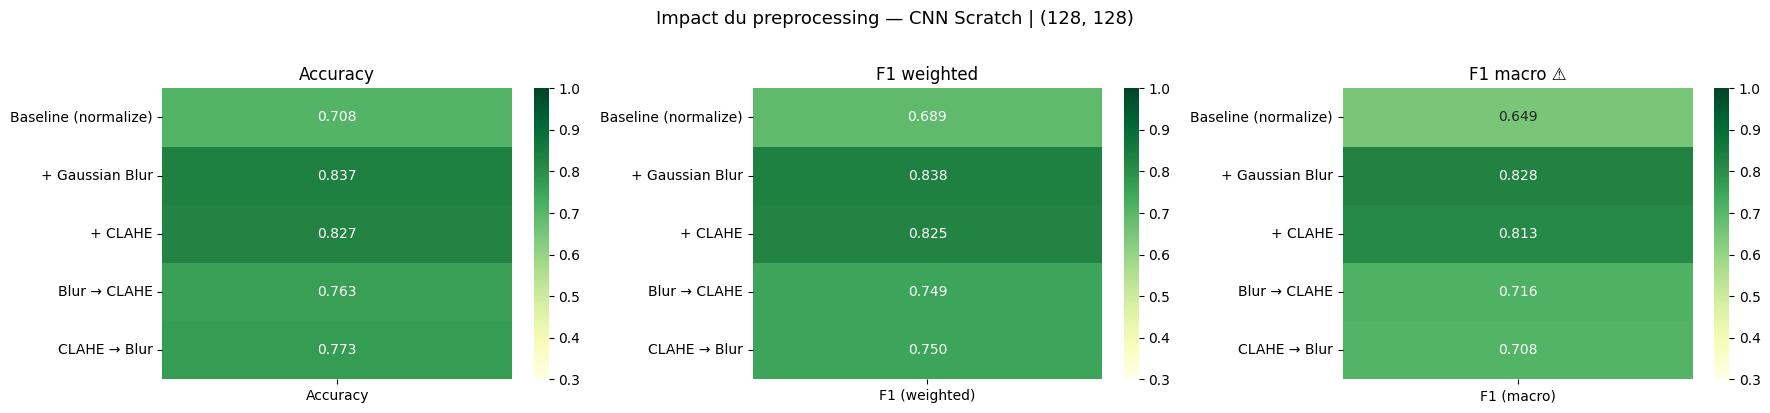

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, n_exp * 0.8)))

for ax, col, title in zip(axes,
                           ["Accuracy", "F1 (weighted)", "F1 (macro)"],
                           ["Accuracy", "F1 weighted", "F1 macro ⚠️"]):
    data = df_results[[col]]
    sns.heatmap(data, annot=True, fmt=".3f", cmap="YlGn",
                vmin=0.3, vmax=1, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("")

plt.suptitle(f"Impact du preprocessing — CNN Scratch | {IMG_SIZE}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 🗺️ 11. Grad-CAM — Zones d'attention du meilleur modèle

**Grad-CAM** (Gradient-weighted Class Activation Mapping) visualise les régions de l'image qui influencent le plus la décision du modèle.  
Sur des images masquées, on s'attend à ce que le modèle se concentre sur les structures **intra-pulmonaires**.

On affiche :
- Les prédictions **correctes** : zones d'attention sur lesquelles le modèle s'appuie pour bien classifier
- Les prédictions **incorrectes** : où le modèle se trompe et pourquoi

In [12]:
def find_last_conv_layer(model):
    """Trouve la dernière couche Conv2D du modèle."""
    last_conv = None
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            last_conv = layer.name
    return last_conv


def make_gradcam_heatmap(model, img_array, conv_layer_name):
    """Génère une heatmap Grad-CAM pour img_array (batch de 1)."""
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        class_output = predictions[:, pred_class]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_class.numpy()


def overlay_gradcam(img, heatmap, alpha=0.45):
    """Superpose la heatmap sur l'image originale."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_s = img.squeeze()
    img_norm = (img_s - img_s.min()) / (img_s.max() - img_s.min() + 1e-8)
    img_rgb = np.uint8(255 * np.stack([img_norm] * 3, axis=-1))
    return cv2.addWeighted(img_rgb, 1 - alpha, heatmap_colored, alpha, 0)


print("Fonctions Grad-CAM chargées.")

Fonctions Grad-CAM chargées.


In [13]:
# ── Collecte d'exemples corrects et incorrects sur le meilleur modèle ──
best_model = best['model']
best_test_ds = best['test_ds']

correct_examples   = {cls: [] for cls in CLASS_NAMES}
incorrect_examples = {cls: [] for cls in CLASS_NAMES}
N_EXAMPLES = 3

for images, labels in best_test_ds:
    preds = best_model.predict(images, verbose=0)
    for i in range(len(images)):
        true_label = np.argmax(labels[i].numpy())
        pred_label = np.argmax(preds[i])
        cls = CLASS_NAMES[true_label]
        if true_label == pred_label and len(correct_examples[cls]) < N_EXAMPLES:
            correct_examples[cls].append(images[i].numpy())
        elif true_label != pred_label and len(incorrect_examples[cls]) < N_EXAMPLES:
            incorrect_examples[cls].append((images[i].numpy(), CLASS_NAMES[pred_label]))

print("Exemples collectés :")
for cls in CLASS_NAMES:
    print(f"  {cls}: {len(correct_examples[cls])} corrects, {len(incorrect_examples[cls])} incorrects")

Exemples collectés :
  COVID: 3 corrects, 3 incorrects
  Lung_Opacity: 3 corrects, 3 incorrects
  Normal: 3 corrects, 3 incorrects
  Viral Pneumonia: 3 corrects, 3 incorrects


Dernière couche Conv2D : conv_256


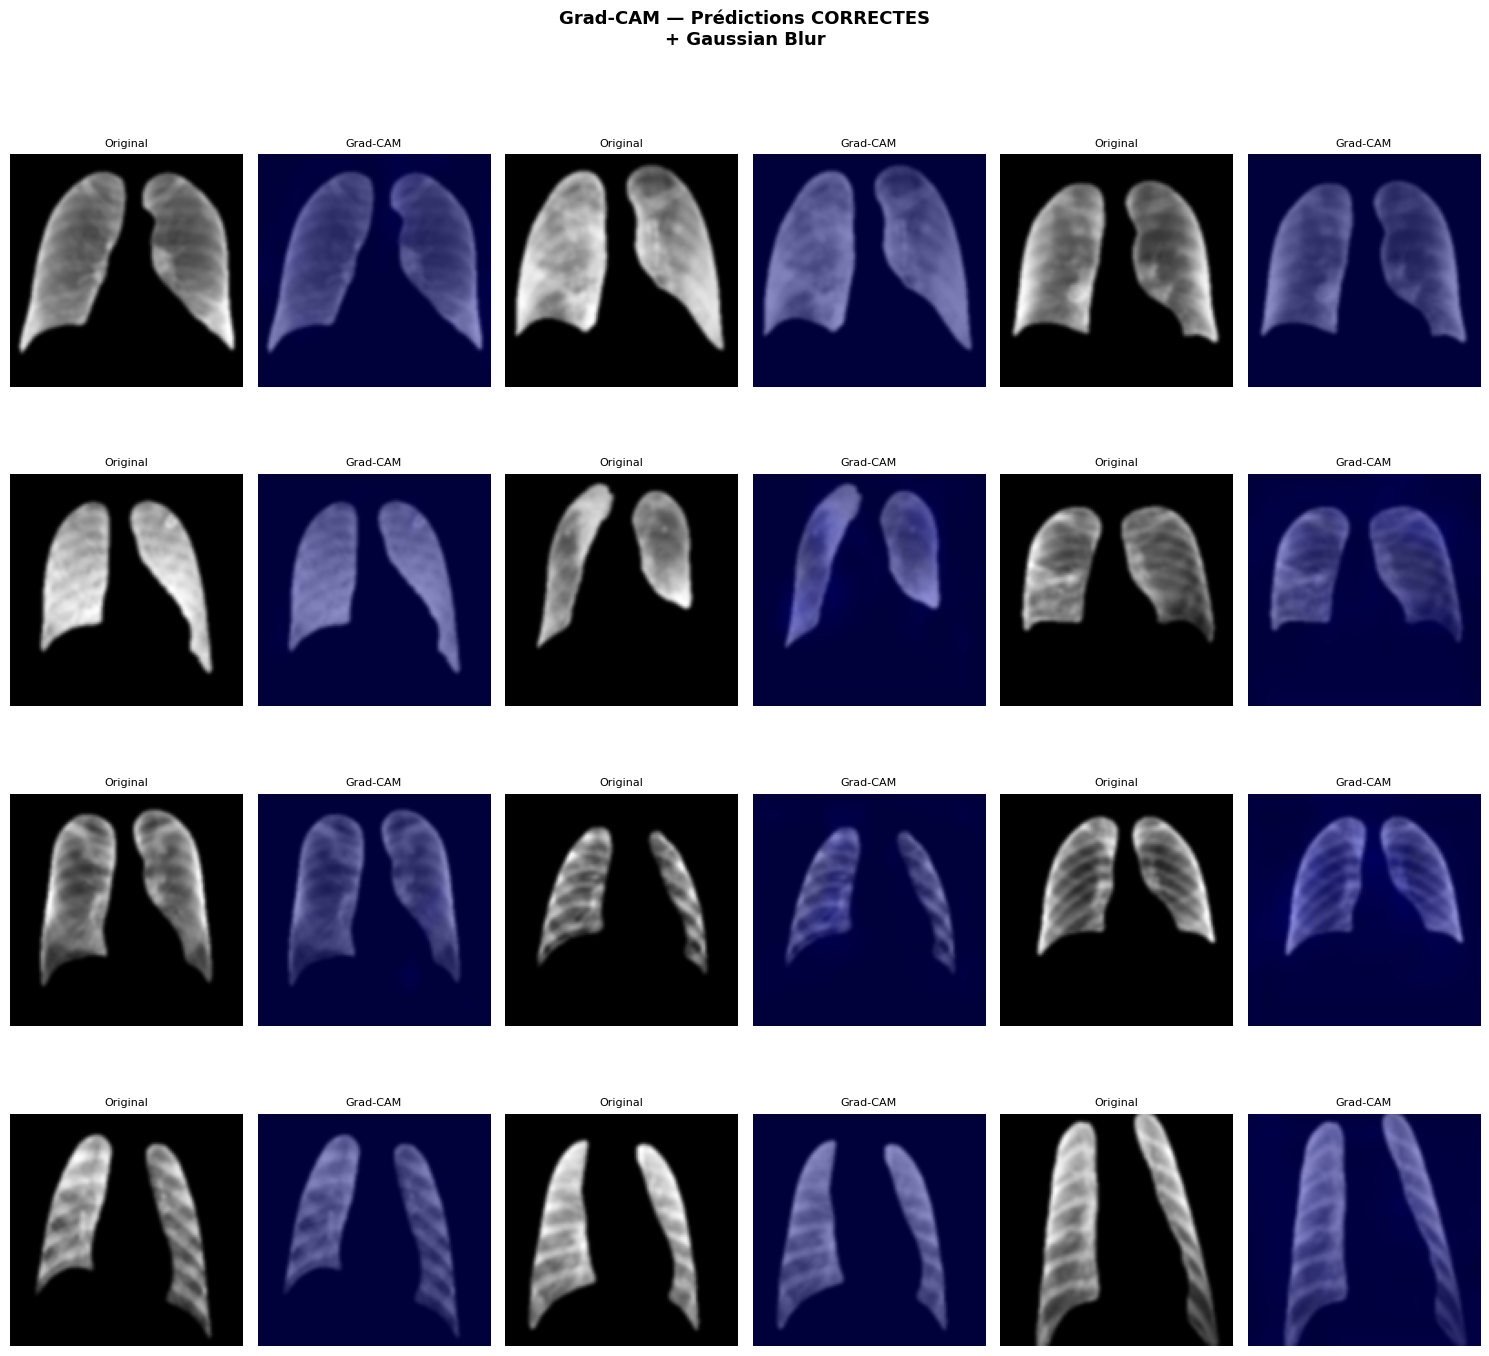

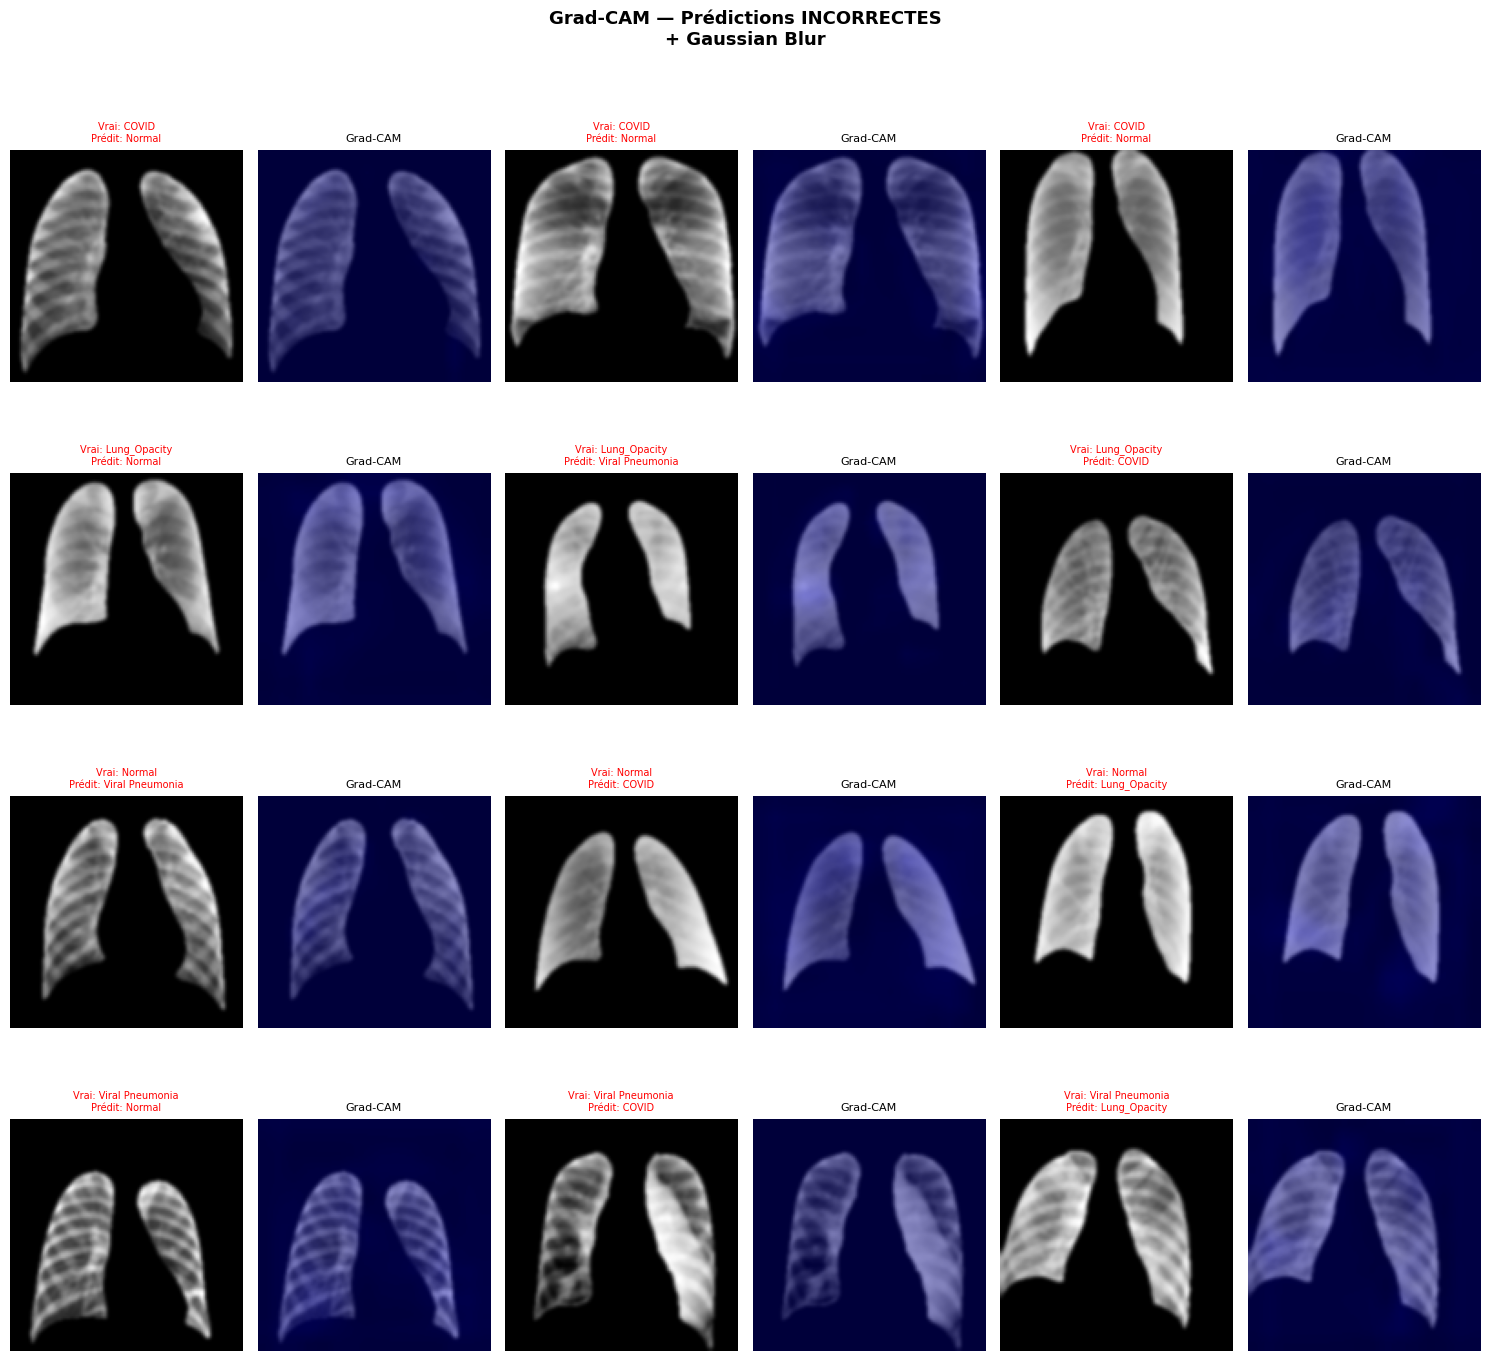

In [14]:
last_conv = find_last_conv_layer(best_model)
print(f"Dernière couche Conv2D : {last_conv}")

# ── Grad-CAM — Prédictions CORRECTES ──
fig, axes = plt.subplots(NUM_CLASSES, N_EXAMPLES * 2, figsize=(N_EXAMPLES * 5, NUM_CLASSES * 3.5))
fig.suptitle(f"Grad-CAM — Prédictions CORRECTES\n{best_name}", fontsize=13, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASS_NAMES):
    examples = correct_examples[cls]
    for j in range(N_EXAMPLES):
        ax_img = axes[i, j * 2]
        ax_cam = axes[i, j * 2 + 1]
        if j < len(examples):
            img = examples[j]
            heatmap, _ = make_gradcam_heatmap(best_model, np.expand_dims(img, 0), last_conv)
            overlay = overlay_gradcam(img, heatmap)
            ax_img.imshow(img.squeeze(), cmap='gray')
            ax_img.set_title("Original", fontsize=8)
            ax_cam.imshow(overlay)
            ax_cam.set_title("Grad-CAM", fontsize=8)
        else:
            ax_img.axis('off')
            ax_cam.axis('off')
        if j == 0:
            ax_img.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0, labelpad=80)
        ax_img.axis('off')
        ax_cam.axis('off')

plt.tight_layout()
plt.show()

# ── Grad-CAM — Prédictions INCORRECTES ──
has_incorrect = any(len(v) > 0 for v in incorrect_examples.values())
if has_incorrect:
    fig, axes = plt.subplots(NUM_CLASSES, N_EXAMPLES * 2, figsize=(N_EXAMPLES * 5, NUM_CLASSES * 3.5))
    fig.suptitle(f"Grad-CAM — Prédictions INCORRECTES\n{best_name}", fontsize=13, fontweight='bold', y=1.01)
    for i, cls in enumerate(CLASS_NAMES):
        examples = incorrect_examples[cls]
        for j in range(N_EXAMPLES):
            ax_img = axes[i, j * 2]
            ax_cam = axes[i, j * 2 + 1]
            if j < len(examples):
                img, pred_cls = examples[j]
                heatmap, _ = make_gradcam_heatmap(best_model, np.expand_dims(img, 0), last_conv)
                overlay = overlay_gradcam(img, heatmap)
                ax_img.imshow(img.squeeze(), cmap='gray')
                ax_img.set_title(f"Vrai: {cls}\nPrédit: {pred_cls}", fontsize=7, color='red')
                ax_cam.imshow(overlay)
                ax_cam.set_title("Grad-CAM", fontsize=8)
            else:
                ax_img.axis('off')
                ax_cam.axis('off')
            if j == 0:
                ax_img.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0, labelpad=80)
            ax_img.axis('off')
            ax_cam.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Aucune prédiction incorrecte à afficher.")